Model Evaluation (Initial Decision Tree)
Validation Accuracy: 0.9750
Test Accuracy: 0.9800

Classification Report (Validation Set):
                  precision    recall  f1-score   support

        Diabetic       0.99      0.98      0.99       169
    Non-Diabetic       0.87      1.00      0.93        20
Predict-Diabetic       0.91      0.91      0.91        11

        accuracy                           0.97       200
       macro avg       0.92      0.96      0.94       200
    weighted avg       0.98      0.97      0.98       200



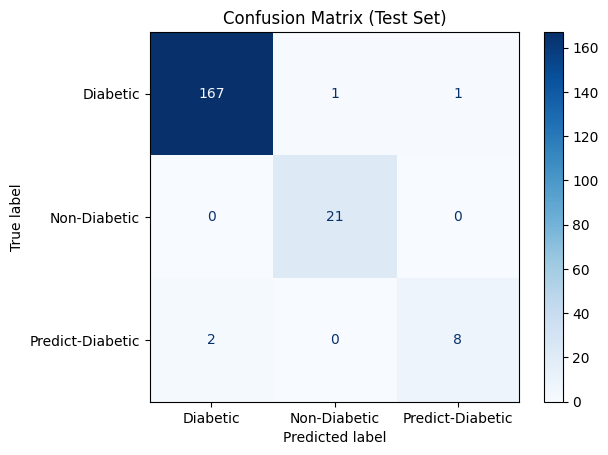


 Best Parameters Found:
{'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_split': 2}

 Optimized Model Performance:
Validation Accuracy: 0.9750
Test Accuracy: 0.9750


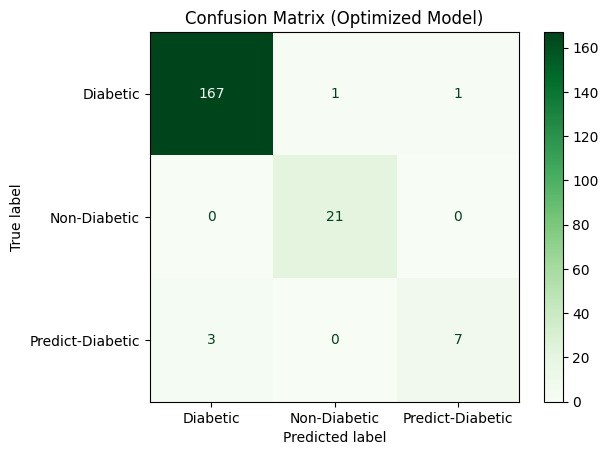


Classification Report (Optimized Model):
                  precision    recall  f1-score   support

        Diabetic       0.98      0.99      0.99       169
    Non-Diabetic       0.95      1.00      0.98        21
Predict-Diabetic       0.88      0.70      0.78        10

        accuracy                           0.97       200
       macro avg       0.94      0.90      0.91       200
    weighted avg       0.97      0.97      0.97       200



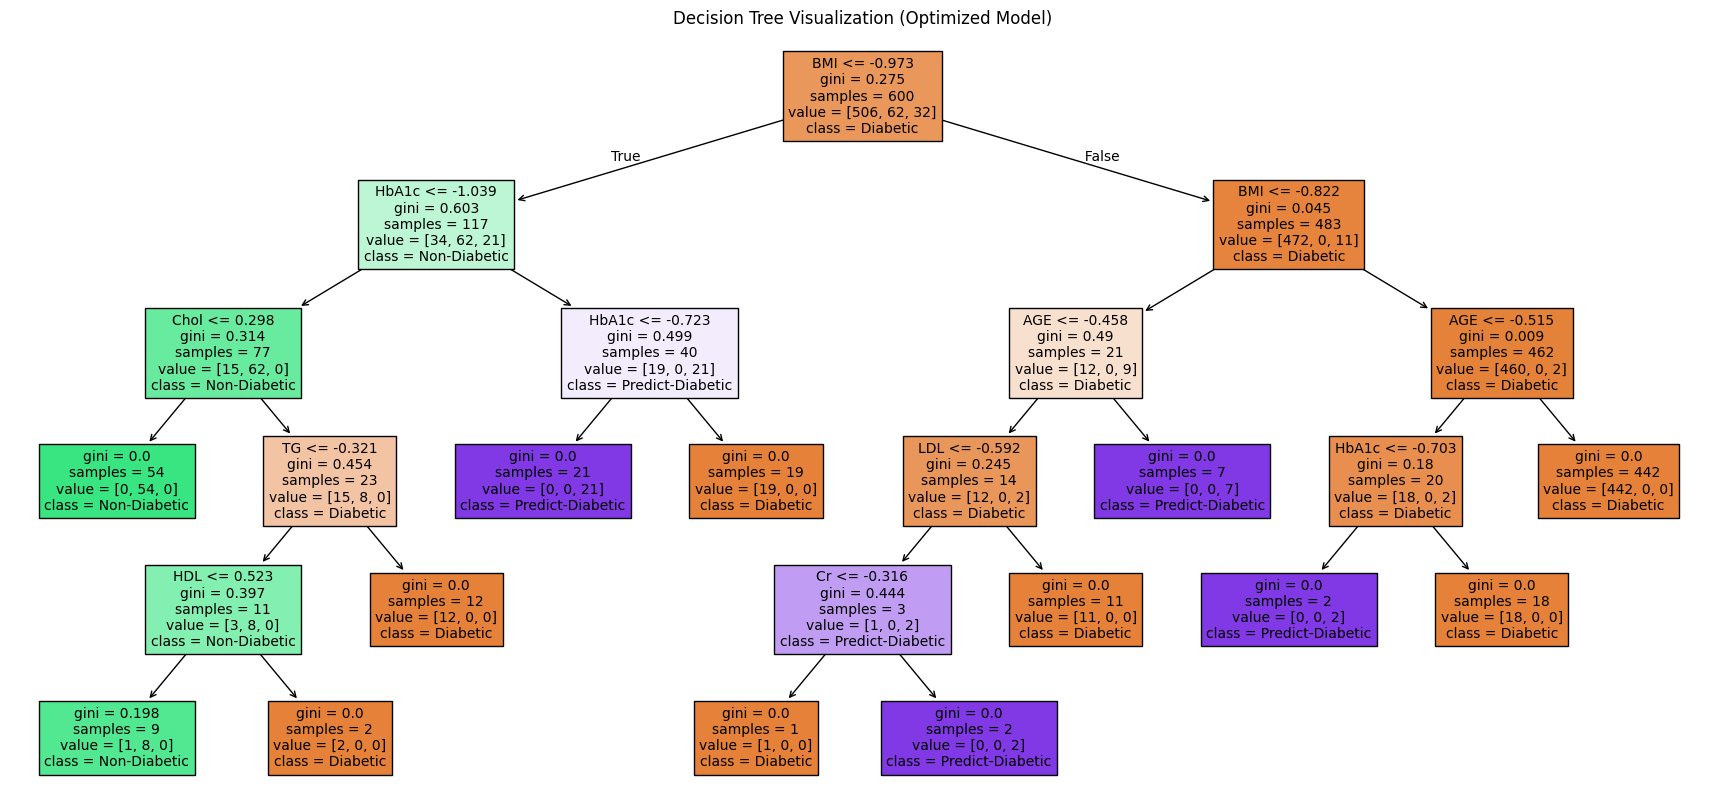

In [25]:
#  Model Evaluation & Visualization

# Focus: Evaluate model performance, reduce overfitting, visualize results

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

#  Make predictions on validation and test sets
y_pred_val = dt_model.predict(X_val)
y_pred_test = dt_model.predict(X_test)

# Evaluate performance
print("Model Evaluation (Initial Decision Tree)")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(y_val, y_pred_val, target_names=class_encoder.classes_))

#  Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_encoder.classes_)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Test Set)")
plt.show()

#
#  Overfitting (Hyperparameter Tuning)
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=23),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

#  model and parameters
print("\n Best Parameters Found:")
print(grid_search.best_params_)

final_dt_model = grid_search.best_estimator_

# Evaluate after tuning
y_pred_val_final = final_dt_model.predict(X_val)
y_pred_test_final = final_dt_model.predict(X_test)

print("\n Optimized Model Performance:")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val_final):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_final):.4f}")

#
# Confusion Matrix (Optimized Model)
cm_final = confusion_matrix(y_test, y_pred_test_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=class_encoder.classes_)
disp_final.plot(cmap="Greens", values_format='d')
plt.title("Confusion Matrix (Optimized Model)")
plt.show()

print("\nClassification Report (Optimized Model):")
print(classification_report(y_test, y_pred_test_final, target_names=class_encoder.classes_))

#
# Visualize Final Decision Tree
feature_names = [col for col in ds.columns if col != 'CLASS']

plt.figure(figsize=(22, 10))
plot_tree(
    final_dt_model,
    filled=True,
    feature_names=feature_names,
    class_names=class_encoder.classes_,
    fontsize=10
)
plt.title("Decision Tree Visualization (Optimized Model)")
plt.show()
